# Multinomial Naive Bayes demonstration

Multinomial Naive Bayes is a natural model for text classification because documents can be represented by word counts. This notebook uses a tiny, hand-written dataset so that the calculation remains visible and runs immediately.

The model's inductive bias is strong: words contribute class evidence independently once the class is known. Additive smoothing, controlled by `alpha`, prevents an unseen word from making an entire class probability zero.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from algorithms.multinomial_naive_bayes import multinomial_naive_bayes_classifier

# Each document is already tokenized: one list of words per example.
X_train = [
    ['team', 'wins', 'match'],
    ['player', 'scores', 'goal'],
    ['team', 'strong', 'defense'],
    ['coach', 'plans', 'match'],
    ['election', 'policy', 'debate'],
    ['minister', 'announces', 'policy'],
    ['government', 'passes', 'law'],
    ['voters', 'discuss', 'election'],
]
y_train = ['sports', 'sports', 'sports', 'sports', 'politics', 'politics', 'politics', 'politics']

X_test = [
    ['team', 'scores', 'goal'],
    ['coach', 'wins', 'match'],
    ['minister', 'debate', 'policy'],
    ['voters', 'passes', 'law'],
]
y_test = ['sports', 'sports', 'politics', 'politics']

# Learn the vocabulary from training documents only. Unknown test words are ignored.
vocab = sorted({word for document in X_train for word in document})
print(f'training documents={len(X_train)}, test documents={len(X_test)}')
print(f'vocabulary size={len(vocab)}')
print(vocab)

training documents=8, test documents=4
vocabulary size=20
['announces', 'coach', 'debate', 'defense', 'discuss', 'election', 'goal', 'government', 'law', 'match', 'minister', 'passes', 'plans', 'player', 'policy', 'scores', 'strong', 'team', 'voters', 'wins']


## From documents to probabilities

The classifier first counts words within each class. For a class such as `sports`, it estimates how likely each vocabulary word is under that class. With log probabilities, multiplying many small probabilities becomes addition, which is numerically safer.

The prediction rule is proportional to `P(class) × product(P(word | class) ** count)`. The word-count vector therefore preserves repeated words rather than only recording whether a word appears.

In [2]:
# Log space avoids underflow when a document contains several words.
model = multinomial_naive_bayes_classifier(alpha=1.0, log_scale=True)
model.fit(X_train, y_train, vocab)
predictions = model.predict(X_test)

accuracy = np.mean(np.asarray(predictions) == np.asarray(y_test))
print('predictions:', predictions)
print(f'test accuracy: {accuracy:.2f}')

# Priors show how common each class is before reading a document.
print('class log-priors:', model.class_prior_probabilities)
word_probabilities = pd.DataFrame(model.word_probabilities_given_class, index=vocab)
word_probabilities.loc[['team', 'goal', 'policy', 'election']]

predictions: ['sports', 'sports', 'politics', 'politics']
test accuracy: 1.00
class log-priors: {'sports': -0.6931471805599453, 'politics': -0.6931471805599453}


,sports,politics
team,-2.367124,-3.465736
goal,-2.772589,-3.465736
policy,-3.465736,-2.367124
election,-3.465736,-2.367124


## What does smoothing change?

`alpha` adds a small pseudo-count to every word in every class. With no smoothing, a word absent from one class would receive probability zero and dominate the product. Larger smoothing values make word probabilities more uniform, weakening the influence of individual words.

The following sweep keeps the dataset and vocabulary fixed, then plots test accuracy and F1 for six smoothing strengths. On a real dataset, this parameter would be selected using a validation split rather than by repeatedly inspecting the test set.

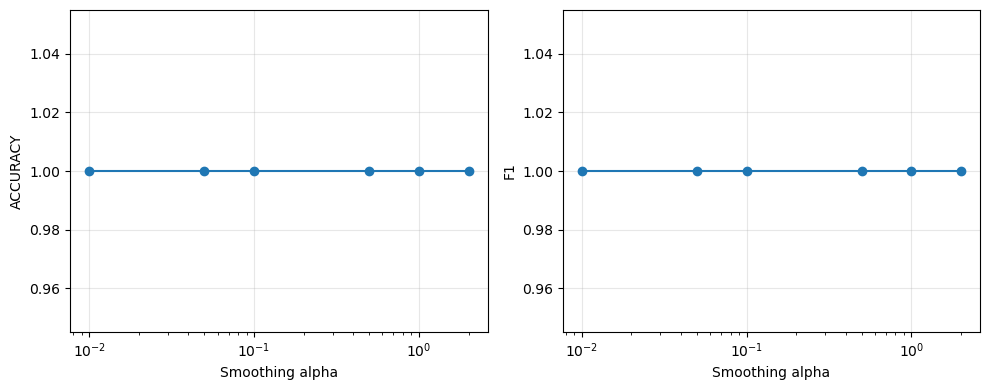

,alpha,accuracy,f1
0,0.01,1.0,1.0
1,0.05,1.0,1.0
2,0.10,1.0,1.0
3,0.50,1.0,1.0
4,1.00,1.0,1.0
5,2.00,1.0,1.0


In [3]:
def f1_score(labels, predictions, positive_label='politics'):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    true_positive = np.sum((labels == positive_label) & (predictions == positive_label))
    false_positive = np.sum((labels != positive_label) & (predictions == positive_label))
    false_negative = np.sum((labels == positive_label) & (predictions != positive_label))
    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    return 2 * precision * recall / max(precision + recall, 1e-12)

# Compare very light to stronger smoothing.
alphas = (0.01, 0.05, 0.1, 0.5, 1.0, 2.0)
rows = []
for alpha in alphas:
    classifier = multinomial_naive_bayes_classifier(alpha=alpha, log_scale=True)
    classifier.fit(X_train, y_train, vocab)
    predicted = classifier.predict(X_test)
    rows.append({
        'alpha': alpha,
        'accuracy': np.mean(np.asarray(predicted) == np.asarray(y_test)),
        'f1': f1_score(y_test, predicted),
    })

performance = pd.DataFrame(rows)
results_dir = Path('results/naive_bayes')
figures_dir = Path('figures/naive_bayes')
results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
performance.to_csv(results_dir / 'alpha_sweep.csv', index=False)

figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, metric in zip(axes, ('accuracy', 'f1')):
    axis.plot(performance['alpha'], performance[metric], marker='o')
    axis.set_xscale('log')
    axis.set_xlabel('Smoothing alpha')
    axis.set_ylabel(metric.upper())
    axis.grid(True, alpha=0.3)
figure.tight_layout()
figure.savefig(figures_dir / 'alpha_sweep.png', bbox_inches='tight')
plt.show()
performance

## Interpretation

Naive Bayes is fast because training reduces each class to a prior and a table of word probabilities. Its simplicity is also its main limitation: real words are not conditionally independent, and word order is discarded by the bag-of-words representation.

When reading the table and plot, ask which words provide strong class evidence and whether changing `alpha` changes the decision. This is the model's inductive bias made visible: frequent class-specific words matter, while smoothing controls how strongly the model trusts those word counts.